In [27]:
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN, MSE
import torch
from pyPLNmodels.models import IMPS_PLN, log_likelihood, fastPLN, fastPLNPCA, PLNmodel
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Device  cpu


In [28]:
import seaborn

In [51]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
torch.cuda.is_available()
# print('device ', device)

False

## Importation of the data

In [31]:
Y = pd.read_csv('example_data/Y_test')
O = pd.read_csv('example_data/O_test')
cov = pd.read_csv('example_data/cov_test')
true_Sigma = torch.from_numpy(pd.read_csv('example_data/true_Sigma_test').values)
true_beta = torch.from_numpy(pd.read_csv('example_data/true_beta_test').values)

## Test aggregated class

Fitting a PLNPCA model with importance sampling. Number of PCs:  50
Intialization ...
Initalization done


  2%|▏         | 18/1000 [00:08<08:06,  2.02it/s]


KeyboardInterrupt: 

Best likelihood:  -96.4591630607758


AttributeError: Please fit the model before by calling model.fit(Y,O,covariates)

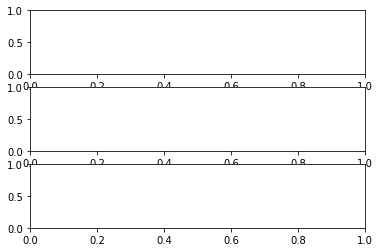

In [9]:
mypln = PLNmodel(10)
%time mypln.fit(Y,O,cov, fast = False)
print(mypln)

##  Test fastPLN model

In [132]:
n = 200

Device  cpu
Initialization ...
nb iteration to find the mode:  200
Initialization finished
Last delta: 0.0180994261621521,  reached in 26 iterations
CPU times: user 18.6 s, sys: 7.56 ms, total: 18.6 s
Wall time: 1.17 s
Best likelihood:  95.08684665899956


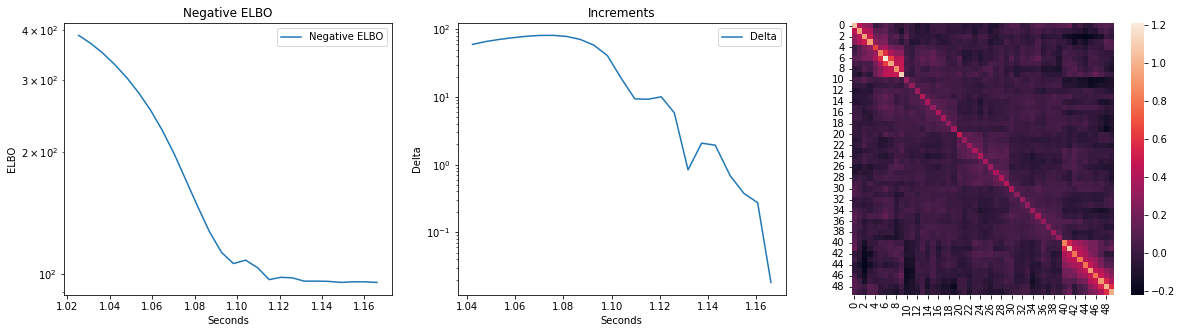

<Figure size 432x288 with 0 Axes>

In [54]:
fast = fastPLN()
%time fast.fit(Y,O,cov)
print(fast)

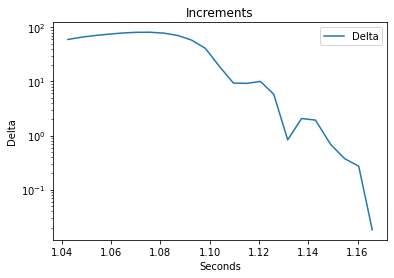

In [56]:
fast.show_crit(save = True, name_doss = 'testfast')

In [135]:
pcaC = fastpca.get_C()
pcaSigma = pcaC@(pcaC.T)
#fast.Sigma = pcaSigma
fast.compute_ELBO()/n
#fast.compute_ELBO()
#sns.heatmap(pcaSigma.cpu())

tensor(-1.9375e+13, device='cuda:0', grad_fn=<DivBackward0>)

## Test fastPLNPCA

Initialization ...
nb iteration to find the mode:  78
Initialization finished
Tolerance 0.001 reached in 722 iterations
CPU times: user 37.4 s, sys: 39.6 ms, total: 37.4 s
Wall time: 2.35 s
Last ELBO : -96.1902826986181
Dimension of the latent space : 10


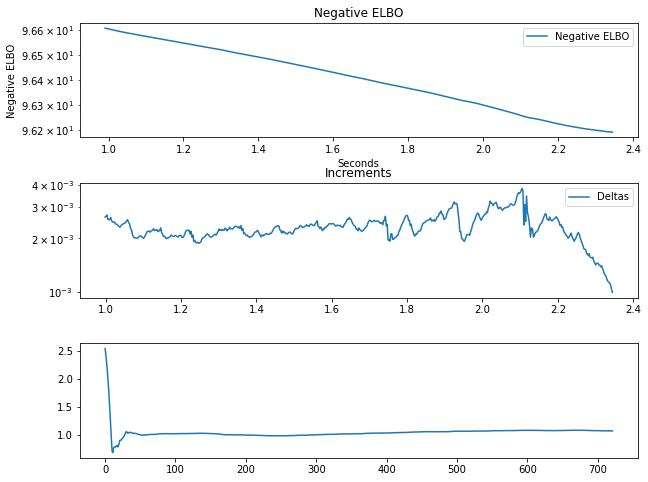

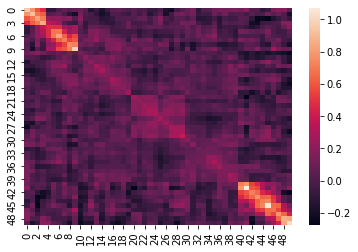

In [59]:
fastpca = fastPLNPCA(q = 10)
%time fastpca.fit(Y,O,cov)


Best likelihood:  -299.77345585583254


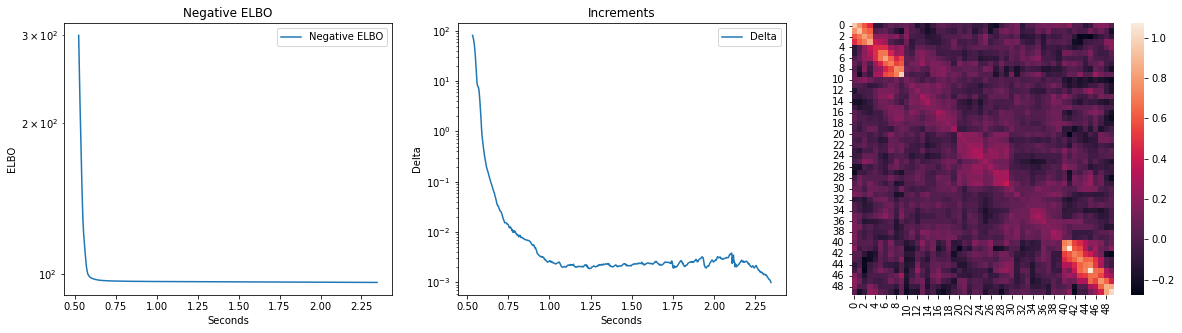

<Figure size 432x288 with 0 Axes>

In [65]:
fastpca.save_stat('test_pca')

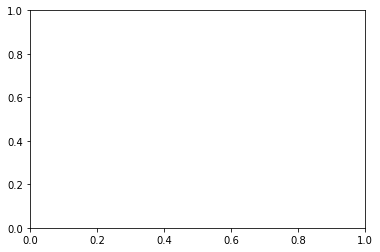

In [67]:
fig, ax = plt.subplots()

tensor(-210.3063, device='cuda:0', grad_fn=<DivBackward0>)

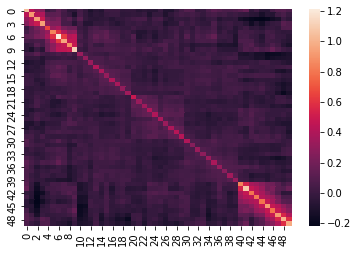

In [142]:
fastC = C_from_Sigma(fast.Sigma, p )
sns.heatmap((fastC@fastC.T).detach().cpu())
fastpca.C = fastC

fastpca.compute_ELBO_PCA()/200

## Test IMPS_PLN

Device  cpu


  5%|▌         | 1/20 [00:01<00:24,  1.28s/it]

Average log likelihood :  -105.88690414648806


 10%|█         | 2/20 [00:02<00:20,  1.13s/it]

Average log likelihood :  -106.24844435687615


...

Average log likelihood :  -104.02792745406049


 95%|█████████▌| 19/20 [00:14<00:00,  1.32it/s]

Average log likelihood :  -103.95990302644415


100%|██████████| 20/20 [00:15<00:00,  1.30it/s]

Average log likelihood :  -103.90873173463618
Best likelihood:  -103.16161080559293


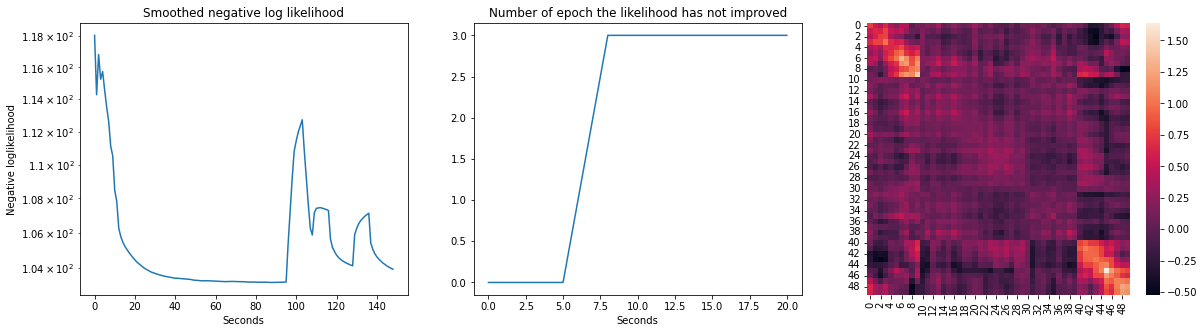

<Figure size 432x288 with 0 Axes>

In [84]:
imps = IMPS_PLN(q = 5)
imps.fit(Y,O,cov, batch_size = 5, verbose = True, nb_plateau = 5, acc = 0.100, N_iter_max = 20)
print(imps)

Best likelihood:  -103.08832043527383


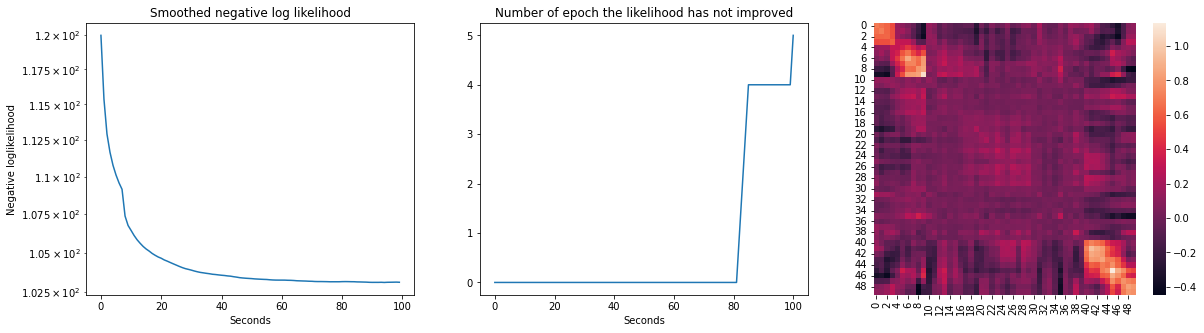

<Figure size 432x288 with 0 Axes>

In [35]:
print(imps)

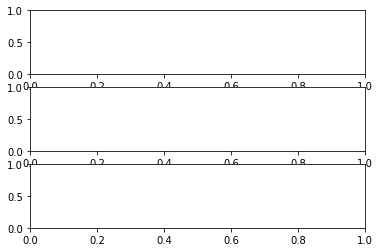

In [37]:
fig, axes = plt.subplots(3,1)

Device  cpu
Best likelihood:  -103.08832043527383


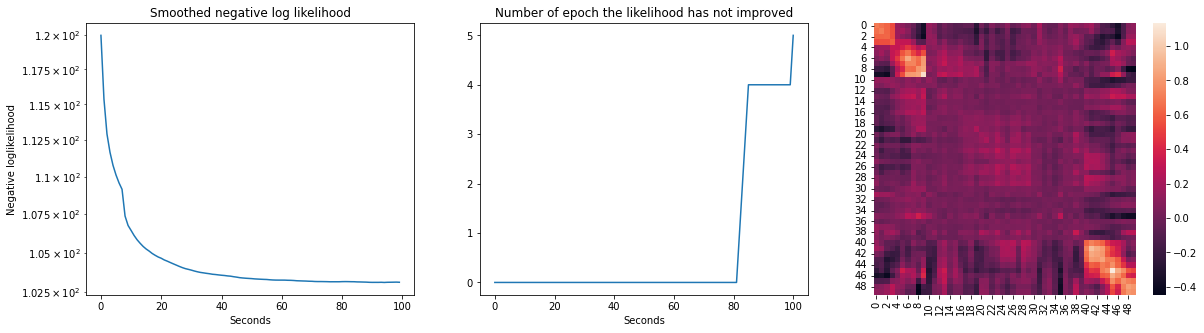

<Figure size 432x288 with 0 Axes>

In [42]:
print(imps)

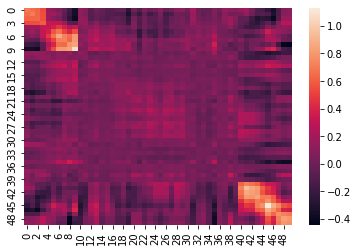

In [48]:
imps.show_Sigma(save = True)

In [41]:
imps.fig.savefig('test')

Best likelihood:  -103.08832043527383


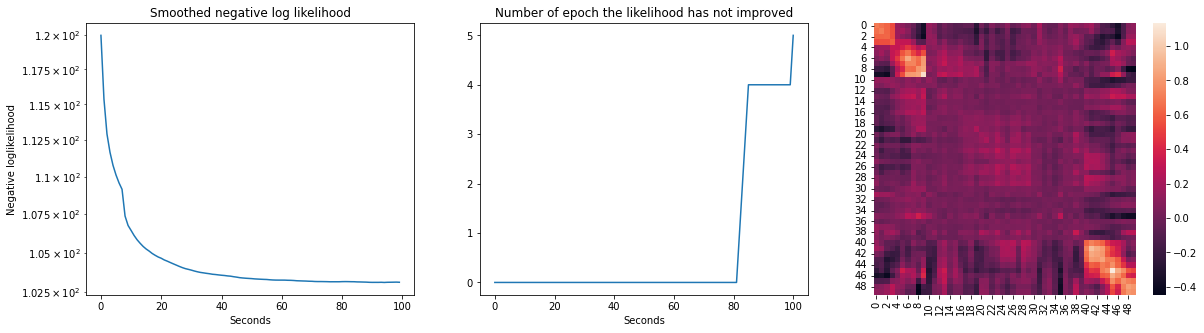

<Figure size 432x288 with 0 Axes>

AttributeError: 'numpy.ndarray' object has no attribute 'show'

In [36]:
imps.save_stat('test')

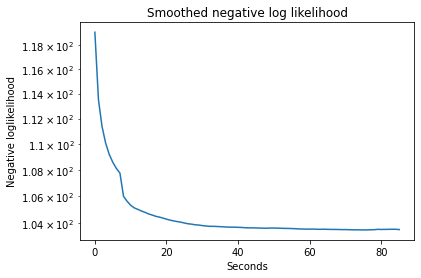

In [19]:
imps.show_loss(save = True)

In [15]:
print('beta : ', imps.get_beta())
print('Sigma:', imps.get_Sigma())
print('C : ', imps.get_C())

beta :  tensor([[ 0.5319, -0.1286, -0.9118,  0.2196, -0.5501,  0.7098, -0.0512,  0.1287,
          0.5618,  0.6380, -0.1822, -0.0517, -1.0352, -1.4089, -1.0043, -0.9508,
         -1.5333, -0.7870, -0.2195,  1.3637, -0.5500, -0.3784,  0.4841, -1.3099,
          0.9395, -0.0897, -0.9752, -0.6879,  0.7681,  0.0425, -0.0818, -1.1697,
         -0.0794,  0.0716,  0.1251, -1.3632,  1.2246, -0.2534,  2.3016, -0.1352,
          0.1280, -0.3523,  0.5177, -0.7209, -0.1243,  0.5502,  0.7485,  0.3261,
         -1.0124, -0.2889],
        [-0.3688,  0.6966, -0.0611,  0.3833, -1.0528, -0.9435, -0.0092,  0.0033,
         -0.8806, -0.8904, -0.5710, -0.7291,  0.4935, -0.3190, -0.3351,  0.2781,
         -0.2219, -0.0509, -0.1223, -0.0372, -0.7687, -1.3786,  0.3807, -0.3960,
         -0.4027, -0.8715, -0.3271,  0.2408, -0.2199,  0.2229,  0.3529, -0.1587,
         -0.6257,  0.6852, -0.7469,  0.1797,  0.2518, -0.5882, -0.0730, -0.5182,
          0.5133,  0.5887,  0.1786,  0.5281, -0.6902,  1.6824,  0.5284, -

## True value of Sigma 

<AxesSubplot:>

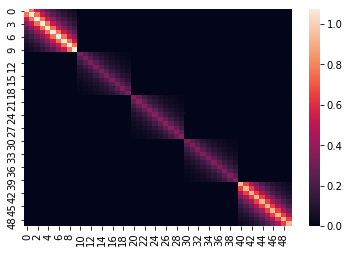

In [16]:
sns.heatmap(true_Sigma)

<AxesSubplot:>

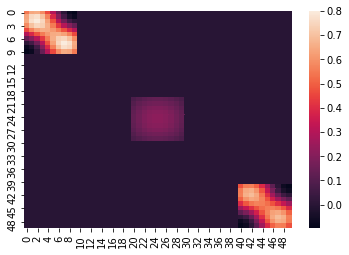

In [18]:
true_C = C_from_Sigma(true_Sigma, 5)
sns.heatmap(true_C@(true_C.T))

# Poisson lognormal model
## Optimisation with machine-learning techniques
### B. Batardière, J. Chiquet, J. Kwon + PLN team<br /><br /> <small>MIA Paris-Saclay, AgroParisTech, INRAE</small> <br /> <small>Last update 21 March, 2022</small>

---






# Poisson lognormal Model

.pull-left2[
Let

<br/>

We observe

]slide

.pull-right2[
- `\(n\)` be the number of sites/cells/samples
- `\(p\)` the number of species/genes/variables
- `\(d\)` the number of environmental covariates
- `\(n\)` measures of the joint counts `\(Y_i\in\mathbb{N}^p\)`
- `\(n\)` measures of the environment covariates matrix `\(X_i\in\mathbb{R}^d\)`
]

`$$\begin{aligned}
Z_{i} &= \beta^{\top} X_i + CW_i, \qquad W_{i} \sim \mathcal{N}\left(0, I_{q}\right) \\[1.25ex]
Y_{i j}  \mid Z_{i j} & \sim \mathcal{P}\left(\exp \left( Z_{i j}\right)\right) \\
\end{aligned}$$`

where `\(q\leq p\)` is the dimension of the latent space. The model parameters encompass

  - The matrix of regression parameters `\(\beta = (\beta _{kj})_{1 \leq k \leq d, 1 \leq j \leq p}\)`,
  - The matrix `\(C \in \mathbb R^{p\times q}\)` sending the latent variable `\(W_i\)` from `\(\mathbb{R}^q\)` to `\(\mathbb{R}^p\)`.

If `\(p = q\)`, `\(\theta = (\beta, \Sigma = C^T C)\)`, .important[standard PLN], see [AH89; CMR21]

If `\(q < p\)`, `\(\theta = (\beta, C)\)`, .important[PLN-PCA], see [CMR18]

---

# .small[Example for visualization of single-cell data]

A dataset containing the counts of the 500 most varying transcripts in the mixtures of 5 cell lines in human liver, for a total of 3918 cells



<img src="optimPLN_files/figure-html/unnamed-chunk-2-1.png" width="50%" style="display: block; margin: auto;" />

`\(\rightsquigarrow\)` `R` implementation with V-EM and standard non linear optimization techniques works up to hundreds of variables and thousands of samples. Can we do better? .important[ML + Pytorch] [Pas+17]

---

# Inference

`$$\text{We wish to solve } \hat{\theta} = \arg\max _{\theta}\log p_{\theta}(Y) = \arg\max _{\theta} \sum _{i =1} ^n \log p_{\theta}(Y_i)$$`

### .content-box-red[.small[Approximated Expectation-Maximization (Variational EM), [BKM99; CMR18]]]

.content-box-yellow[

`$$\textrm{Solves iteratively } \theta^{t+1}=\arg\max_{\theta, \, q\in\mathcal{Q}} \; \sum_{i=1}^n J_i(\theta, \psi_i) = \log p_{\theta}(Y_i)-K L\left[q(W_i) \|  p_{\theta}(W_i \mid Y_i)\right]$$`

`$$\text{where } J_i(\theta, \psi) = \mathbb{E}_{q_i ;\theta^{t}}\left[\log p_{\theta}(Y_i, W_i) \mid Y_i\right] - \mathbb{E}_{q_i ;\theta^{t}} [\log q_i(W_i;\psi_i)]$$`

and `\(q_i(.; \psi_i) \in \mathcal{Q} = \{ \mathcal{N}\left(M_{i}, \operatorname{diag} (S_{i}\odot S_i )), M_i \in \mathbb{M} ^q, S_i \in \mathbb{R}^q\right\}\)`.
]

### .content-box-red[.small[Direct optimization by approximating the gradient of the objective]]

.content-box-yellow[

`$$\nabla_{\theta} \sum _{i =1} ^n \log p_{\theta}(Y_i) = \sum _{i =1} ^n \nabla_{\theta}  \log \left(  \int_{R^q} p_{\theta} (Y_i|W_i) p(W_i)\mathrm{d} W_i \right).$$`
- Ingredient 1: Stochastic-gradient method with variance reduction
- Ingredient 2: Monte-Carlo estimation and importance sampling. 
]

---

# Variational EM

### PLN

`$$Y_{i}  \mid Z_{i} \sim \mathcal{P}\left(\exp \left( Z_{i}\right)\right), Z_{i} \sim\mathcal{N}(\beta^{\top} X_i, \Sigma)$$`

- M step is explicit : for fix `\(\psi_i = (M_i,S _i)\)`, then

`$$\hat{\Sigma} = \frac{1}{n} \sum_{i}\left(\left((M^{(t)}-X\beta)_{i} (M^{(t)}-X\beta)_{i}\right)^{\top}+S^{(t)}_{i}\right), \quad\hat{\beta} = (X^{\top}X)^{-1}X^{\top}M^{(t)}$$`

- E-step: for fix `\(\theta\)` to `\(\hat{\theta}\)`, solve in `\(\psi_i\)` by gradient ascent

### PLN-PCA

Joint gradient ascent on `\((\theta, \psi) = (C, \beta, {M_i, S_i, i=1,\dots,n})\)`

### Tuning

- Use Rprop [RB93] to solve the gradient ascent
  - SGD with momentum/adaptive learning rate
  - Use the sign of the gradient + one learning rate per parameter

---

# Performance of V-EM

<div class="figure" style="text-align: center">
<img src="Comparison_fastPLN_vs_fastPLNPCA_n=1000.png" alt="Running times for `\(n=1000, q=10, d=1\)`." width="60%" />
<p class="caption">Running times for `\(n=1000, q=10, d=1\)`.</p>
</div>

.pull-left2[
PLN

PLN-PCA

]

.pull-right2[
- convergence in a small number of iterations
- `\(\mathcal{O}(n p + p^2)\)` parameters to optimize + inversion of `\(\hat{\Sigma} (p\times p)\)`
- convergence for a large number of iterations,
- `\(\mathcal{O}(n p + p q)\)` parameters to optimize + inversion of `\(\hat{\Sigma} (q\times q)\)`
]

---

# Direct Gradient Ascent: .small[first ingredient]

Optimize a convex function `\(f(\theta) = \sum_{i} f_i(\theta)\)`.

### Stochastic Gradient Descent (SGD)

`$$\begin{aligned}
\text{For } & t=1,\dots,T \\
& i_t\sim\mathcal{U}([1,..,n]\\
& \theta_{t+1} \leftarrow \theta - \eta \nabla f_{i_t}(\theta_t)\\
\end{aligned}$$`

### SGD with Variance Reduction (SAGA, [RB93])

`$$\begin{aligned}
\text{For } & t=1,\dots,T \\
& i_t\sim\mathcal{U}([1,..,n]\\
& \theta_{t+1} \leftarrow \theta - \eta \left(\nabla f_{i_t}(\theta_t) - \nabla f_{i_t}(\alpha^t_{i_t}) + \frac{1}{n} \sum_{i=1}^n \nabla f_i (\alpha_i^t) \right) \\
& \text{For } i=1,\dots,n \\
& \quad \alpha_i^{t+1} \leftarrow \mathbf{1}_{\{i_t = i\}} \theta_t + \mathbf{1}_{\{i_t \neq i\}} \alpha_i^t \\
\end{aligned}$$`

- stabilize the estimation of the gradient by averaging
- need to store all the gradients
- other variants (SVRG, [+19])

---

# Direct Gradient Ascent: .small[second ingredient]

In our average SGD algorithm, we need to estimate `\(\nabla_{\theta} \log p_{\theta}(Y_i) = \mathbb{E}_{W} \left[p_\theta(Y_i|W) \right]\)`.

Let `\(\tilde p_{\theta} = p_{\theta}(Y_i| W_i) p(W_i)\)` (explicit) and `\(n_s\)` the sampling effort. MC approach solves

`$$p_{\theta}(Y_i) = \int \tilde p_{\theta}(W_i) \mathrm dW_i \approx \frac 1 {n_s} \sum_{k=1}^{n_s} \tilde p_{\theta}, \text{ where } W_i \sim\mathcal{N}(0,I_q)$$`
`\(\rightsquigarrow\)` `\(\tilde p_{\theta}\)` has little mass near zero, huge variance, poor approximation.

### Importance Sampling

Consider a density function `\(\phi\)` (the importance law). Importance sampling relies on

`$$\mathbb{E}_{W} \left[p_\theta(Y_i|W) \right] = \mathbb{E}_\phi \left[ \frac{p_\theta(Y_i|W) p(W)}{\phi(W)}\right].$$`
To estimate `\(p_\theta\)` as follows:

`$$p_{\theta}(Y_i) = \int \tilde p_{\theta}(W) \mathrm dW \approx \frac 1 {n_s} \sum_{k=1}^{n_s} \frac {\tilde p_{\theta}(V_k)}{\phi(V_k)}, \quad (V_{k})_{1 \leq k \leq n_s} \overset{iid}{\sim} \phi(.)$$`

---

# Choice of the importance law

### Optimal choice

The IS estimator is consistent, with variance depending on `\(\phi\)`. The optimal choice is such as

`$$\phi_{opt}(V_i) = \frac{\tilde{p}_{\theta}(V_i)}{p_\theta(Y_i)} = p(V_i|Y_i)$$`
### Practical choice

We chose `\(\phi(V) \sim \mathcal{N}(\mu, \Sigma)\)` with  

`$$\hat{\mu} = \arg\max_\mu \log p(W_i|Y_i) = \arg\max_\mu \log \tilde{p}(W_i)$$`
that we solve numerically (thank you Pytorch).

For the Covariance,

`$$\hat{\Sigma}^{-1} = \frac{\partial^2}{\partial^2 W_i} \log \tilde{p}(W_i)\Bigg\vert_{W=\hat{\mu}} = - I_q - C^\top \text{diag}(\exp(X_i^\top \beta + C W)) C\Bigg\vert_{W=\hat\mu}$$`


---

# Gradient approximation

`$$\nabla _{\theta} \operatorname{log} p_{\theta}(Y_i) \approx \nabla_{\theta} \operatorname{log}\left(\frac 1 {n_s} \sum_{k=1}^{n_s} \frac {\tilde p_{\theta}^{(u)}(V_k)}{g(V_k)}\right)$$`
We have

$$ \tilde{p}_{\theta}(W_i) = \exp \left(  - \frac  12 \| W_i\|^2 - \mathbf{1}_p^{\top} \exp(O_i + \beta^{\top}X_i  + CW_i) + Y_i^{\top}(O_i + \beta^{\top}X_i +CW_i)\right),$$

and derive the gradients formula

`$$\nabla_{\beta} \log p_{\theta}(Y_i)\approx  X_i Y_i^{\top} -\frac{\sum_{i = 1}^{n_s}\frac{\tilde p_{\theta}(V_k)}{\phi(V_k)}X_i\exp(O_i + \beta^{\top}X_i + C V_k)^{\top}}{\sum_{i = 1}^{n_s}\frac{\tilde p_{\theta}(V_k)}{\phi(V_k)}}$$`

`$$\nabla_{C} \log p_{\theta}(Y_i)\approx \frac{\sum_{i = 1}^{n_s}\frac{\tilde p_{\theta}(V_k)}{\phi(V_k)}\left[Y_{i}- \exp \left(O_i +  \beta^{\top} X_{i}+C V_{k}{ }\right)\right]  V_{k}^{\top}}{\sum_{i = 1}^{n_s}\frac{\tilde p_{\theta}(V_k)}{\phi(V_k)}}$$`


Given the estimated gradients, we can run a gradient ascent to increase the likelihood. We use algorithm of Variance reduction such as SAGA.

---

# V-EM vs Importance Sampling

Example with `\(n=p=1000\)`, `\(d=1, q=10\)`, Toeplitz (AR-like) covariance

<img src="ELBOvslikelihood.png" width="100%" style="display: block; margin: auto;" />

- orange: ELBO of the V-EM
- red: log-likelihood found by IMPS at convergence
- blue: log-likelihood computed with current V-EM estimates




---

# PLN Python package

### Installation

Clone the github repository


```bash
git clone https://github.com/pln-team/pyPLNmodels
```

Create an environment


```bash
conda create --name pyPLNmodels
conda activate pyPLNmodels
```

Install Pytorch (see  [https://pytorch.org/](https://pytorch.org/))


```bash
conda install pytorch torchvision torchaudio cudatoolkit=10.2 -c pytorch
```

Install the module  `pyPLNmodels` with dependencies


```bash
pip install pyPLNmodels
```


---
  
  
# PLN Python package
  
### Load the package
  
Amaizingly works from `RStudio` with **reticulate** correctly configured:
  

```r
library(reticulate)
use_condaenv("pyPLNmodels")
```

Once included, then in a Python chunk, you need


```python
from pyPLNmodels.models import PLNmodel, fastPLN, fastPLNPCA, IMPS_PLN
```

```
## Device  cpu
```

### Load the data
  
In Python, (data set with `\(p = 50, n = 200, d = 2\)`)


```python
import pandas as pd 
Y = pd.read_csv("Y.csv")
X = pd.read_csv("X.csv")
O = pd.read_csv("O.csv")
```

---
  
# Fast PLN
  

```python
mypln = fastPLN()
mypln.fit(Y, O , X)
```

```python
mypln.show(save=True)
```

<img src="optimPLN_files/figure-html/fastPLN-oaks-1.png" width="960" style="display: block; margin: auto;" /><img src="optimPLN_files/figure-html/fastPLN-oaks-2.png" width="960" style="display: block; margin: auto;" />

---
  
# Fast PLN-PCA
  

```python
q = 5
myplnpca = fastPLNPCA(q)
myplnpca.fit(Y, O, X)
```

```python
myplnpca.show(save=True)
```

<img src="optimPLN_files/figure-html/unnamed-chunk-5-5.png" width="960" style="display: block; margin: auto;" /><img src="optimPLN_files/figure-html/unnamed-chunk-5-6.png" width="960" style="display: block; margin: auto;" />

---

# Importance Sampling for PLN-PCA


```python
q = 5
imps = IMPS_PLN(q)
imps.fit(Y, O, X)
```

```python
imps.show(save=True)
```

<img src="optimPLN_files/figure-html/unnamed-chunk-6-9.png" width="960" style="display: block; margin: auto;" />


---
# References

Aitchison, J. and C. H. Ho (1989). "The multivariate Poisson-log normal
distribution". In: _Biometrika_ 76.4, pp. 643-653. ISSN: 0006-3444.
DOI:
[10.1093/biomet/76.4.643](https://doi.org/10.1093%2Fbiomet%2F76.4.643).
eprint:
https://academic.oup.com/biomet/article-pdf/76/4/643/706252/76-4-643.pdf.
URL:
[https://doi.org/10.1093/biomet/76.4.643](https://doi.org/10.1093/biomet/76.4.643).

Blei, D. M., A. Kucukelbir, and J. D. McAuliffe

Chiquet, J., M. Mariadassou, and S. Robin (2018). "Variational
inference for probabilistic Poisson PCA".

arXiv: 1703.06633 [stat.ME].

Chiquet, J., M. Mariadassou, and S. Robin (2021). "The
Poisson-lognormal model as a versatile framework for the joint analysis
of species abundances". In: _Frontiers in Ecology and Evolution_ 9, p.
188.

Ge, R., Z. Li, W. Wang, et al. (2019). "Stabilized SVRG: Simple
variance reduction for nonconvex optimization". In: _Conference on
learning theory_. PMLR. , pp. 1394-1448.

Paszke, A., S. Gross, S. Chintala, et al. (2017). "Automatic
differentiation in PyTorch".

Riedmiller, M. A. and H. Braun (1993). "A direct adaptive method for
faster backpropagation learning: the RPROP algorithm". In: _IEEE
International Conference on Neural Networks_, pp. 586-591 vol.1.